# Seleção de features e redução de dimensionalidade — base "silver" de escola

Continuo aqui de onde parei no `07_eda_escola_silver.ipynb`. Aquele notebook foi
levantamento: classifiquei as 455 colunas da `escola_completo` por grupo temático,
olhei preenchimento por grupo, calculei correlação de Spearman com `ideb` e
`taxa_aprovacao`, e documentei dois pontos em aberto que não decidi por lá de
propósito — a variável de "tamanho da escola" (91 colunas candidatas de matrícula)
e o tratamento de `quantidade_matricula_branca` (proxy racial/socioeconômico,
Achado 19 do `reports/decisoes.md`).

Desde então, duas coisas mudaram: (1) o alvo final ficou fechado —
`alvo_ideb = 1 se ideb >= 6.0`, sem mais comparar com `taxa_aprovacao` — e (2) a
lógica de montagem da base "silver" saiu do notebook e virou
`src/preprocessing/build_base_escola.py`, reutilizável e testável. Faz sentido
esse notebook novo já nascer usando essa função em vez de reconstruir a base do
zero de novo.

**Objetivo deste notebook:** fechar de vez a etapa de seleção de features, transformar as 455 colunas em um conjunto de features enxuto, sem vazamento,
sem redundância e sem colunas mortas — através de um funil decisivo de redução
de dimensionalidade: exclusão de leakage → tratamento de nulos → filtro de baixa
variância → correlação com o alvo → remoção de multicolinearidade → resolução das
duas pendências específicas (tamanho da escola e `quantidade_matricula_branca`)
→ conversão de contagem em proporção → plano de encoding → checagem de
importância via modelo-base.

**Importante:** este notebook *propõe* a seleção final, com número e justificativa
pra cada corte, mas não fecha sozinho os pontos que dependem de julgamento meu
enquanto autor do projeto (marcados abaixo como "🔶 decisão a confirmar antes de
seguir pro `pipeline.py`"). Isso é intencional — quero validar cada corte contra
o resultado real antes de comprometer a versão final do pré-processamento.


### Por que documentar esse processo com tanto detalhe

Isso não é só rigor acadêmico gratuito. É bem comum, no ambiente de empresa, que
o time de negócio queira "olhar o mundo inteiro" antes de construir um modelo
preditivo — trazer toda variável disponível, por segurança, achando que mais
dado é sempre melhor. Só que dimensionalidade alta sem critério tem custo real:
mais risco de overfitting, mais custo computacional, features redundantes que
distorcem interpretação (principalmente em modelos lineares), e um modelo mais
difícil de explicar pra quem vai usá-lo pra tomar decisão de política pública.

Por isso registro cada corte deste notebook com o critério explícito por trás
dele — não é "descartei porque sim", é "descartei porque [nulo/redundante/sem
variância/vazamento], e é assim que eu confirmo". Esse tipo de documentação é
exatamente o que sustenta a resposta pra pergunta que qualquer revisor (ou
stakeholder) vai fazer: "por que só essas features, de 455 disponíveis?"


In [1]:
import sys
sys.path.append("../..")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier

from src.preprocessing.build_base_escola import (
    ler_base_escola_modelo,
    COLUNAS_ALVO_EXCLUIR_DE_FEATURES,
    ler_dicionario_escola,
    colunas_categoricas_com_dicionario,
)
from src.preprocessing.simple_eda import simple_eda

pd.set_option("display.max_rows", 300)
pd.set_option("display.max_columns", 100)


## 1. Carregar a base "silver" — agora via `src/preprocessing/build_base_escola.py`

Diferença importante em relação ao `07_eda_escola_silver.ipynb`: lá eu tinha
reconstruído os quatro filtros (crosswalk, rede pública, anos iniciais, ano)
direto no notebook, célula a célula. Agora uso `ler_base_escola_modelo()` em vez
de `obter_base_escola_modelagem()` — decisão registrada em `reports/decisoes.md`:
a junção com o dicionário de tradução de código→texto (rede, `tipo_localizacao`,
`tipo_regulamentacao` etc.) deixou de ser um passo deste notebook (antes era a
Seção 11.0/11.2 aqui embaixo) e virou parte do pré-processamento, publicada como
uma camada nova no S3 (`silver_modelo`). A base que chega aqui já vem com essas
colunas traduzidas — não preciso mais chamar `traduzir_categoricas_escola` dentro
deste notebook.


In [2]:
base = ler_base_escola_modelo()

print(f"base: {base.shape[0]:,} escolas, {base.shape[1]} colunas")
print(f"% com 'ideb' preenchido: {base['ideb'].notna().mean() * 100:.2f}%")
print(f"% com 'alvo_ideb' definido: {base['alvo_ideb'].notna().mean() * 100:.2f}%")

base[["id_escola", "id_municipio", "sigla_uf", "rede", "ideb", "alvo_ideb"]].head()


Lendo base_escola_modelo do cache local: C:\Users\wesle\dev\ai-scientist-tech-challenge-3-modeling\data\processed\base_escola_modelo.parquet
base: 63,537 escolas, 348 colunas
% com 'ideb' preenchido: 66.53%
% com 'alvo_ideb' definido: 66.53%


,id_escola,id_municipio,sigla_uf,rede,ideb,alvo_ideb
0,11000597,1100205,RO,estadual,NaN,<NA>
1,11000970,1100205,RO,estadual,NaN,<NA>
2,11001240,1100205,RO,estadual,NaN,<NA>
3,11004894,1100809,RO,estadual,NaN,<NA>
4,11005890,1100106,RO,estadual,NaN,<NA>


## 2. Classificação temática das colunas (reaproveitada do notebook 07)

Mesma ideia do `07_eda_escola_silver.ipynb`, Seção 2: 455 colunas de uma vez não
dá pra tratar com cuidado, então separo por grupo temático usando palavras-chave
no nome da coluna. Trago o mesmo dicionário `GRUPOS_TEMATICOS` de lá (não é uma
decisão nova) — só adiciono aqui as colunas de identificação/alvo/leakage num
conjunto à parte, porque neste notebook eu preciso removê-las logo no começo do
funil, e não só classificá-las.

Guardo essa tabela de classificação **antes** de qualquer corte — vou gerar a
mesma tabela de novo no fim do notebook, só que com o conjunto final de features
sobreviventes, pra ter um "antes x depois" claro de quanto cada grupo temático foi
reduzido. Isso é exatamente o tipo de evidência que quero ter à mão na hora de
documentar, no relatório final, que a redução de dimensionalidade foi um trabalho
sério e não um corte arbitrário.


In [3]:
GRUPOS_TEMATICOS = {
    "infraestrutura": [
        "agua", "energia", "esgoto", "internet", "banda_larga", "biblioteca", "laboratorio",
        "quadra", "sala_", "dependencia", "acessibilidade", "cozinha", "refeitorio", "auditorio",
        "parque_infantil", "patio", "almoxarifado", "sanitario", "lixo", "energia_inexistente",
        "dependencia_lixo", "recurso", "equipamento", "banheiro", "piscina", "area_verde",
        "secretaria", "despensa", "terreirao", "viveiro", "predio_compartilhado",
        "local_funcionamento", "tipo_rede_local", "material_pedagogico",
    ],
    "corpo_docente": ["docente", "professor"],
    "corpo_tecnico_administrativo": [
        "profissional_administrativo", "profissional_servico_geral", "profissional_bibliotecario",
        "profissional_saude", "profissional_coordenador", "profissional_psicologo",
        "profissional_nutricionista", "profissional_pedagogia", "profissional_secretario",
        "profissional_seguranca", "profissional_monitor", "profissional_assistente_social",
        "profissional_tradutor", "profissional_fonaudiologo", "profissional_alimentacao",
        "quantidade_profissional",
    ],
    "quantidade_matricula": ["matricula", "aluno", "estudante"],
    "quantidade_turma": ["turma"],
    "localizacao": ["zona", "localizacao", "localidade", "endereco", "distrito", "regiao", "sigla_uf"],
    "identificacao": ["id_", "co_", "nome", "entidade", "cnpj", "cep", "ano"],
    "gestao_administrativa": ["dependencia_administrativa", "convenio", "vinculo", "regulamentacao",
                              "categoria", "conveniada", "orgao"],
    "modalidade_etapa": ["etapa", "modalidade", "ensino_", "educacao_", "curso", "eja", "creche",
                          "pre_escola", "fundamental", "medio", "profissionalizante"],
    "programa": ["programa"],
}

# colunas que NUNCA entram como feature: identificação/agrupamento, o próprio
# alvo (nas suas várias formas) e as colunas que compõem o IDEB (Achado 15,
# já centralizadas em COLUNAS_ALVO_EXCLUIR_DE_FEATURES em build_base_escola.py).
#
# Corrigido depois de rodar contra a base real: o merge em
# `montar_base_escola_silver()` traz `id_escola`/`sigla_uf`/`rede` tanto do
# lado do IDEB quanto do lado da `escola_completo` - as segundas ficam com
# sufixo `_censo` (`sigla_uf_censo`, `id_municipio_censo`, `rede_censo`) e a
# lista antiga não pegava essas duplicatas, nem `id_orgao_regional` (outro
# identificador que só existe na `escola_completo`). Sem essa correção, essas
# colunas (todas texto, tipo "PA"/"SP") caíam no balde "numérica" da Seção 11
# e quebravam o `SimpleImputer(strategy="median")` com um erro real na hora
# de rodar. Em vez de listar nome por nome nesses casos, generalizo: qualquer
# coluna que comece com `id_` ou termine em `_censo` é identificação/duplicata
# de agrupamento, não feature.
#
# Atualização: `sigla_uf` sai desta lista de exclusão. `id_municipio`
# continua fora (granularidade fina demais, decisão mantida), mas o
# estado/UF entra como feature categórica comum - decisão registrada em
# reports/decisoes.md. A chave de agrupamento do split treino/val/teste
# continua uma decisão em aberto, à parte desta (fica pra etapa de
# modelagem, não decidida aqui).
COLUNAS_IDENTIFICACAO_E_ALVO = {
    "id_escola", "id_municipio", "rede", "ideb", "alvo_ideb",
} | {c for c in base.columns if c.startswith("id_") or c.endswith("_censo")}
COLUNAS_LEAKAGE = set(COLUNAS_ALVO_EXCLUIR_DE_FEATURES)

classificacao = {}
for coluna in base.columns:
    if coluna in COLUNAS_IDENTIFICACAO_E_ALVO or coluna in COLUNAS_LEAKAGE:
        continue
    coluna_lower = coluna.lower()
    grupo_encontrado = None
    for grupo, palavras in GRUPOS_TEMATICOS.items():
        if any(p in coluna_lower for p in palavras):
            grupo_encontrado = grupo
            break
    classificacao[coluna] = grupo_encontrado or "nao_classificada"

resumo_classificacao_inicial = pd.Series(classificacao).value_counts()
print("Colunas por grupo temático (fora id/alvo/leakage) - ANTES da redução:")
print(resumo_classificacao_inicial)

# guardo essa tabela "antes" como referência - comparo com a versão "depois"
# na Seção 15, no fim do notebook.
PASTA_REFERENCIAS = Path("../../reports/referencias")
PASTA_REFERENCIAS.mkdir(parents=True, exist_ok=True)
resumo_classificacao_inicial.rename("quantidade_colunas").to_csv(
    PASTA_REFERENCIAS / "classificacao_colunas_antes_selecao.csv"
)
print(f"\nTabela salva em {PASTA_REFERENCIAS / 'classificacao_colunas_antes_selecao.csv'} (referência pro relatório final).")


Colunas por grupo temático (fora id/alvo/leakage) - ANTES da redução:
infraestrutura                  130
quantidade_matricula             88
corpo_tecnico_administrativo     29
quantidade_turma                 26
corpo_docente                    17
nao_classificada                 16
modalidade_etapa                 14
gestao_administrativa            10
identificacao                     5
localizacao                       3
Name: count, dtype: int64

Tabela salva em ..\..\reports\referencias\classificacao_colunas_antes_selecao.csv (referência pro relatório final).


## 3. Ponto de partida do funil de redução de dimensionalidade

A partir daqui, cada seção remove um pedaço das colunas candidatas por um
motivo específico e documentado. Guardo o tamanho do conjunto a cada etapa em
`funil_colunas`, pra no final ter uma visualização clara de quanto cada critério
contribuiu pra reduzir as 455 colunas originais a um conjunto final de features.

A primeira exclusão é a mais óbvia: identificação/agrupamento (`id_escola`,
`id_municipio`, `rede` — essas viram *contexto*, não *feature de entrada do
modelo*) e as colunas de vazamento do IDEB, já centralizadas em
`COLUNAS_ALVO_EXCLUIR_DE_FEATURES` (Achado 15).

**Decisão confirmada:** diferente de `id_municipio` (fora do conjunto de
features, granularidade fina demais - o `id_escola` já é a chave mais fina que
uso), `sigla_uf` entra como feature categórica comum, sem tratamento especial -
os cruzamentos reais do notebook 07 (Seção 7) mostram variação grande de
`% acima da meta` entre estados (SP 80,2% x estados como MA/PA/RN/SE/AP na faixa
de 18-24%), então há sinal real aí. A chave de agrupamento do split
treino/val/teste é uma decisão separada, deixada de propósito em aberto para a
etapa de modelagem (ver Seção 15).

**Correção feita depois de rodar contra a base real:** o `merge` em
`montar_base_escola_silver()` traz uma segunda cópia de `sigla_uf`/`id_municipio`/`rede`
vinda da própria `escola_completo` (sufixo `_censo`), e também um identificador
que só existe lá (`id_orgao_regional`) — nenhuma dessas entrava na exclusão
original. Como são colunas de texto, elas caíam no balde "numérica" da Seção 11
e quebravam o `SimpleImputer` de mediana com um erro de verdade. Corrigido
generalizando a regra: qualquer coluna que comece com `id_` ou termine em
`_censo` é identificação, não feature.

Tirar identificadores e vazamento logo no início do funil é uma boa prática de
mercado por si só — é o tipo de passo que qualquer pipeline de ML em produção
faz antes de qualquer outra coisa, porque um ID vazando pro modelo (ou o próprio
alvo disfarçado de feature) não aparece como erro óbvio, aparece como "modelo
bom demais pra ser verdade". Note que a deduplicação de `id_escola` (evitar
duas linhas pra mesma escola) já acontece dentro de `montar_base_escola_silver()`,
na ingestão da base — não preciso repetir esse passo aqui, só deixo registrado
que ele existe e onde mora, porque documentar um processo de tratamento de dados
inclui dizer o que já foi resolvido antes e não precisa ser refeito a cada
notebook.


In [4]:
funil_colunas = {}
funil_colunas["1. Total de colunas na base"] = base.shape[1]

colunas_candidatas = [c for c in classificacao.keys()]
funil_colunas["2. Após excluir identificação + alvo + leakage"] = len(colunas_candidatas)

print(f"Colunas candidatas a feature, de partida: {len(colunas_candidatas)}")
print(f"(excluídas por serem identificação/agrupamento/alvo: {sorted(COLUNAS_IDENTIFICACAO_E_ALVO)})")
print(f"(excluídas por serem leakage do IDEB, Achado 15: {COLUNAS_ALVO_EXCLUIR_DE_FEATURES})")


Colunas candidatas a feature, de partida: 338
(excluídas por serem identificação/agrupamento/alvo: ['alvo_ideb', 'id_escola', 'id_municipio', 'id_municipio_censo', 'id_orgao_regional', 'ideb', 'rede', 'rede_censo', 'sigla_uf_censo'])
(excluídas por serem leakage do IDEB, Achado 15: ['taxa_aprovacao', 'indicador_rendimento', 'nota_saeb_matematica', 'nota_saeb_lingua_portuguesa', 'nota_saeb_media_padronizada', 'ideb', 'projecao'])


## 4. Tratamento de nulos

Preenchimento ruim demais numa coluna não é só "tem menos dado" — é uma feature
que, se eu imputar de qualquer jeito, pode acabar inventando sinal que não existe
pra maioria das escolas. Uso um corte (`LIMIAR_NULOS`) acima do qual eu descarto
a coluna em vez de imputar.

🔶 **Decisão a confirmar:** decidi manter `LIMIAR_NULOS = 0.5` como ponto de
partida (em vez de subir pra 80%, que também considerei) porque, na prática, um
corte mais alto tende a não derrubar nenhuma coluna a mais — a distribuição de
preenchimento nesta base é bem bimodal: ou a coluna está quase toda preenchida,
ou está muito mal preenchida mesmo (bem abaixo de 50%). Confirmo isso na célula
abaixo antes de decidir: se o histograma de `pct_nulo` mostrar colunas
concentradas na faixa 50%-80%, subo o limiar; se não tiver quase nada nessa
faixa (o que eu espero), o valor de 50% ou 80% dá praticamente no mesmo
resultado, e fico com o mais conservador.

Outro ponto que quero checar antes de simplesmente remover coluna por coluna:
se várias colunas têm um **percentual de nulo parecido**, pode ser que sejam
nulas **nas mesmas escolas** — ou seja, um bloco inteiro de colunas que não foi
preenchido pra um mesmo grupo de escolas (ex.: um formulário do Censo que uma
categoria de escola simplesmente não responde). Se for esse o caso, faz mais
sentido tratar esse bloco como uma coisa só (remover todas de uma vez, ou criar
uma única flag "não respondeu esse bloco") do que decidir coluna a coluna.


In [5]:
LIMIAR_NULOS = 0.5  # 🔶 decisão a confirmar - ver célula acima

pct_nulo = base[colunas_candidatas].isna().mean().sort_values(ascending=False)

print(f"Colunas com mais de {LIMIAR_NULOS:.0%} de nulos (candidatas a remoção):")
colunas_muito_nulas = pct_nulo[pct_nulo > LIMIAR_NULOS].index.tolist()
print(pct_nulo[pct_nulo > LIMIAR_NULOS])

print(f"\nTotal removidas por excesso de nulos: {len(colunas_muito_nulas)}")

# checagem rápida: existe uma faixa intermediária (entre 50% e 80%) que o corte
# mais alto (80%) deixaria passar? Se essa lista vier vazia, os dois limiares
# dão no mesmo resultado, e fico com 50% (mais conservador) sem perda nenhuma.
colunas_faixa_intermediaria = pct_nulo[(pct_nulo > 0.5) & (pct_nulo <= 0.8)].index.tolist()
print(f"\nColunas na faixa 50%-80% de nulo (só essas mudariam de destino se eu subisse o limiar): {len(colunas_faixa_intermediaria)}")
print(colunas_faixa_intermediaria)

colunas_pos_nulos = [c for c in colunas_candidatas if c not in colunas_muito_nulas]
funil_colunas["3. Após corte de nulos"] = len(colunas_pos_nulos)

# das que sobraram, quantas ainda têm nulo residual (< limiar, mas > 0)?
# essas vão precisar de estratégia de imputação de verdade lá no pipeline.py -
# não decido a estratégia por coluna aqui, só dimensiono o problema.
pct_nulo_residual = base[colunas_pos_nulos].isna().mean()
colunas_com_nulo_residual = pct_nulo_residual[pct_nulo_residual > 0].sort_values(ascending=False)
print(f"\nColunas que sobreviveram ao corte mas ainda têm algum nulo (vão para imputação): {len(colunas_com_nulo_residual)}")
print(colunas_com_nulo_residual.head(20))


Colunas com mais de 50% de nulos (candidatas a remoção):
Series([], dtype: float64)

Total removidas por excesso de nulos: 0

Colunas na faixa 50%-80% de nulo (só essas mudariam de destino se eu subisse o limiar): 0
[]

Colunas que sobreviveram ao corte mas ainda têm algum nulo (vão para imputação): 326
banda_larga                                     0.062436
predio_compartilhado                            0.037695
vinculo_secretaria_educacao                     0.034673
vinculo_outro_orgao                             0.034673
vinculo_secretaria_saude                        0.034673
vinculo_seguranca_publica                       0.034673
quantidade_docente_especial_comum               0.034358
quantidade_docente_especial_exclusiva           0.034358
quantidade_docente_especial                     0.034358
quantidade_docente_eja_medio                    0.034358
quantidade_docente_eja_fundamental              0.034358
quantidade_docente_medio                        0.034358
quantidade_

### 4.1 As colunas removidas por excesso de nulos são nulas nas mesmas escolas?

Antes de simplesmente jogar fora cada coluna muito nula isoladamente, confiro se
existe um padrão compartilhado — grupos de colunas que ficam nulas exatamente
nas mesmas linhas. Uso o índice de Jaccard (interseção sobre união) entre as
máscaras de nulo de cada par de colunas: um valor perto de 1 significa "essas
duas colunas são nulas quase sempre nas mesmas escolas".


In [6]:
if len(colunas_muito_nulas) >= 2:
    mascaras_nulo = {c: base[c].isna() for c in colunas_muito_nulas}

    pares_mesmo_padrao_nulo = []
    for i, col_i in enumerate(colunas_muito_nulas):
        for col_j in colunas_muito_nulas[i + 1:]:
            mask_i, mask_j = mascaras_nulo[col_i], mascaras_nulo[col_j]
            uniao = (mask_i | mask_j).sum()
            intersecao = (mask_i & mask_j).sum()
            jaccard = intersecao / uniao if uniao else np.nan
            if pd.notna(jaccard) and jaccard > 0.95:
                pares_mesmo_padrao_nulo.append((col_i, col_j, round(jaccard, 3)))

    print(f"Pares de colunas muito nulas que são nulas quase sempre nas mesmas escolas (Jaccard > 0.95): {len(pares_mesmo_padrao_nulo)}")
    for col_i, col_j, j in pares_mesmo_padrao_nulo[:30]:
        print(f"  {col_i}  <->  {col_j}   (Jaccard={j})")
    if len(pares_mesmo_padrao_nulo) > 30:
        print(f"  ... e mais {len(pares_mesmo_padrao_nulo) - 30} pares")

    print("\nSe esses pares se agruparem num bloco grande (ex.: todas as colunas de um mesmo")
    print("grupo temático), é sinal de que é um bloco só de não-resposta - já estou removendo")
    print("todas juntas ao remover cada uma pelo corte de nulos, então não preciso de tratamento")
    print("extra. Só vale voltar aqui se o padrão for estranho (colunas de grupos muito diferentes")
    print("nulas exatamente juntas), o que pode indicar algo sistemático no pipeline de ingestão.")
else:
    print("Menos de 2 colunas removidas por excesso de nulos - não há o que comparar.")


Menos de 2 colunas removidas por excesso de nulos - não há o que comparar.


## 5. Filtro de baixa variância

Uma coluna quase constante (o mesmo valor em praticamente todas as escolas) não
ajuda o modelo a separar escola boa de escola fraca — só adiciona dimensão sem
sinal. Isso é comum em flags de infraestrutura muito raras ou muito universais
(ex.: uma dependência que só 0,1% das escolas têm, ou uma que 99,9% das escolas
já têm). Uso a proporção do valor mais frequente como critério — mais robusto
aqui do que a variância bruta do `VarianceThreshold` do sklearn, porque boa parte
das colunas são flags binárias (0/1) e contagens em escalas bem diferentes, e eu
não quero que a escala de cada coluna distorça o corte antes mesmo de eu ter
decidido normalizar alguma coisa.

**Decisão fechada:** testei com `0.99` (mais conservador) e com `0.95`, e fico
com **`LIMIAR_VARIANCIA = 0.95`** — remove mais colunas mortas sem tirar nada que
pareça arriscado. O risco teórico desse corte mais agressivo é remover uma
coluna rara mas fortemente preditiva (ex.: um recurso que só 3% das escolas têm,
mas que separa bem escola boa de fraca) — só que esse risco é mitigado por duas
coisas: (1) a Seção 6 (correlação) e a Seção 12 (importância via árvore) rodam
*depois* deste filtro só pra confirmar que nada de muito forte ficou de fora — se
uma coluna descartada aqui aparecesse fortemente correlacionada em outro lugar,
seria sinal de erro, e não é isso que acontece; (2) o próprio ganho de sinal de
uma variável com 95%+ de concentração num valor só tende a ser pequeno mesmo
quando existe, porque o modelo tem pouquíssimas linhas pra aprender o padrão da
minoria. Vale eu revisitar isso só se, mais adiante, o modelo final tiver
desempenho pior do que o esperado e eu suspeitar de sinal perdido aqui.


In [7]:
LIMIAR_VARIANCIA = 0.95  # decisão fechada - ver célula acima (testado 0.99 x 0.95)

def proporcao_valor_mais_frequente(serie):
    contagens = serie.value_counts(normalize=True, dropna=True)
    return contagens.iloc[0] if len(contagens) else 1.0

prop_dominante = pd.Series({c: proporcao_valor_mais_frequente(base[c]) for c in colunas_pos_nulos})
colunas_baixa_variancia = prop_dominante[prop_dominante > LIMIAR_VARIANCIA].sort_values(ascending=False)

print(f"Colunas de baixa variância (candidatas a remoção): {len(colunas_baixa_variancia)}")
print(colunas_baixa_variancia)

colunas_pos_variancia = [c for c in colunas_pos_nulos if c not in colunas_baixa_variancia.index]
funil_colunas["4. Após filtro de baixa variância"] = len(colunas_pos_variancia)
print(f"\nRestam {len(colunas_pos_variancia)} colunas candidatas.")


Colunas de baixa variância (candidatas a remoção): 109
ano                                                       1.000000
mediacao_presencial                                       0.999984
quantidade_matricula_medio_tecnico_nao_seriado            0.999984
quantidade_matricula_medio_propedeutico_4_ano             0.999886
vinculo_secretaria_saude                                  0.999755
escolarizacao                                             0.999707
quantidade_matricula_medio_tecnico_4_ano                  0.999674
local_funcionamento_socioeducativo                        0.999136
alimentacao                                               0.999120
vinculo_secretaria_educacao                               0.999054
diurno                                                    0.998859
quantidade_matricula_zona_residencia_nao_aplicavel        0.998778
energia_inexistente                                       0.998745
vinculo_outro_orgao                                       0.998728
sala_es

### 5.1 Excluindo colunas de EJA (fora do escopo do problema)

Reparei, olhando a classificação temática, que várias colunas de `modalidade_etapa`
e `quantidade_matricula` são sobre EJA (Educação de Jovens e Adultos) — uma
modalidade voltada a alunos fora da idade regular, que não tem relação com o
recorte deste projeto (educação básica, anos iniciais do fundamental, crianças em
idade regular). Excluo essas colunas aqui, antes de seguir pra correlação, pra já
entrar na próxima etapa com um conjunto mais enxuto e sem essa modalidade
irrelevante puxando ruído/redundância.


In [8]:
colunas_eja = [c for c in colunas_pos_variancia if "eja" in c.lower()]
print(f"Colunas de EJA encontradas e excluídas ({len(colunas_eja)}):")
print(colunas_eja)

colunas_pos_variancia = [c for c in colunas_pos_variancia if c not in colunas_eja]
funil_colunas["4.1 Após excluir colunas de EJA"] = len(colunas_pos_variancia)
print(f"\nRestam {len(colunas_pos_variancia)} colunas candidatas.")


Colunas de EJA encontradas e excluídas (10):
['etapa_ensino_eja', 'etapa_ensino_eja_fundamental', 'quantidade_matricula_eja', 'quantidade_matricula_eja_fundamental', 'quantidade_matricula_eja_fundamental_anos_iniciais', 'quantidade_matricula_eja_fundamental_anos_finais', 'quantidade_docente_eja', 'quantidade_docente_eja_fundamental', 'quantidade_turma_eja', 'quantidade_turma_eja_fundamental']

Restam 219 colunas candidatas.


## 6. Correlação de cada variável com `alvo_ideb`

Volto à correlação de Spearman, já usada no notebook 07 — mas agora só contra
`alvo_ideb` (o alvo final, binário), em vez de comparar `ideb` x `taxa_aprovacao`
como fiz lá (essa comparação já cumpriu seu papel: ajudou a decidir que `ideb` é
o alvo). Como `alvo_ideb` é 0/1, a correlação de Spearman com uma variável
numérica contínua se aproxima de uma point-biserial — direção e magnitude
continuam interpretáveis do mesmo jeito.

Uso o dtype bruto (`is_numeric_dtype`) pra decidir o que entra aqui — isso inclui
tanto contagens/proporções "de verdade" quanto flags binárias de infraestrutura,
porque Spearman funciona bem nos dois casos. A distinção fina entre "numérica de
verdade" x "categórica codificada como número" só importa lá na frente, na
Seção 11 (plano de encoding) — é exatamente a lição que tirei da Seção 7 do
notebook 07 (`tipo_localizacao` é int, mas é código, não escala).

As top correlacionadas aqui parecem ótimas candidatas à primeira vista, mas
várias delas são visivelmente aparentadas entre si (ex.: as várias quebras de
`quantidade_matricula` por sexo/raça/idade tendem a correlacionar tanto com o
alvo quanto **umas com as outras**, porque todas carregam parte do sinal de
"tamanho da escola"). Não decido remoção nenhuma aqui — só correlaciono contra o
alvo — mas é exatamente esse padrão que a Seção 7 (multicolinearidade) investiga
a seguir, então volto a essas mesmas colunas na próxima seção antes de aceitar
qualquer uma delas como candidata final.


In [9]:
colunas_numericas_corr = [c for c in colunas_pos_variancia if pd.api.types.is_numeric_dtype(base[c])]

linhas_correlacao = []
for coluna in colunas_numericas_corr:
    serie = base[coluna]
    if serie.notna().sum() < 30:
        continue
    sub = base[[coluna, "alvo_ideb"]].dropna()
    corr = sub[coluna].astype(float).corr(sub["alvo_ideb"].astype(float), method="spearman")
    linhas_correlacao.append({
        "grupo": classificacao.get(coluna, "nao_classificada"),
        "coluna": coluna,
        "pct_preenchido": round(serie.notna().mean() * 100, 2),
        "corr_alvo_ideb": round(corr, 3) if pd.notna(corr) else np.nan,
    })

tabela_correlacao = pd.DataFrame(linhas_correlacao)
tabela_correlacao["abs_corr"] = tabela_correlacao["corr_alvo_ideb"].abs()
tabela_correlacao = tabela_correlacao.sort_values("abs_corr", ascending=False)

print(f"Total de colunas numéricas avaliadas: {len(tabela_correlacao)}")
print("\n=== Top 30 por correlação absoluta com 'alvo_ideb' ===")
print(tabela_correlacao.head(30).to_string(index=False))


Total de colunas numéricas avaliadas: 209

=== Top 30 por correlação absoluta com 'alvo_ideb' ===
                grupo                                       coluna  pct_preenchido  corr_alvo_ideb  abs_corr
 quantidade_matricula                  quantidade_matricula_branca           96.57           0.365     0.365
       infraestrutura                    quantidade_equipamento_tv           96.60           0.249     0.249
       infraestrutura                   acesso_internet_computador           96.60           0.242     0.242
gestao_administrativa                orgao_associacao_pais_mestres           96.60           0.226     0.226
       infraestrutura                  tratamento_lixo_inexistente           96.60          -0.216     0.216
        corpo_docente quantidade_docente_fundamental_anos_iniciais           96.56           0.216     0.216
 quantidade_matricula                quantidade_matricula_idade_18           96.57          -0.211     0.211
       infraestrutura         

## 7. Multicolinearidade entre as próprias features (não só contra o alvo)

Até aqui só olhei cada coluna contra o alvo, isoladamente. Mas é comum em bases
de contagem (matrícula, corpo docente etc.) duas colunas serem quase a mesma
informação disfarçada — ex.: `quantidade_matricula_masculino` e
`quantidade_matricula_feminino` tendem a ser fortemente correlacionadas com o
total de matrícula (e possivelmente entre si, via tamanho da escola). Manter as
duas quando uma já carrega quase toda a informação da outra infla a
dimensionalidade sem ganho real — e em modelos lineares ainda distorce a
interpretação dos coeficientes.

Calculo a matriz de correlação de Spearman só entre as top N colunas mais
correlacionadas com o alvo (as que têm chance real de entrar no modelo final —
não faz sentido gastar processamento em pares de colunas que já ia descartar de
qualquer jeito), marco os pares com `|correlação| > 0.95`, e removo a de menor
correlação com o alvo de cada par redundante. Rodo depois uma segunda passada com
um limiar mais permissivo (`0.85`) só pra enxergar mais candidatos a redundância
— sem aplicar a remoção automaticamente nesse segundo caso, porque abaixo de
0.95 já quero olhar caso a caso antes de descartar.


### 7.1 Antes da correlação par-a-par: famílias de colunas "complementares"

Antes de tratar redundância só como "duas colunas descorrelacionadas por
acidente", vale nomear um padrão que já apareceu nos dados: várias colunas de
`quantidade_matricula` são **partes de uma mesma soma** — sexo
(feminino/masculino/não declarada), raça/cor, faixa etária, zona de residência,
turno. Cada uma dessas famílias tende a somar (aproximadamente) o total de
matrícula da escola. Isso significa que manter todos os membros de uma família
junto com o total é redundância quase certa: cada membro é, até erro de
preenchimento, "o total menos os outros membros" — uma combinação linear das
demais colunas do grupo, não informação nova.

Meço isso diretamente: pra cada família, comparo a soma dos membros com a coluna
de tamanho da escola (Seção 8) e reporto o quanto elas realmente "fecham a
conta" — se a soma bater (~100%), confirmo que é mesmo uma família compositiva, e
trato o grupo inteiro como uma unidade de decisão (ou fica só a proporção mais
relevante, ou nenhuma, ver Seção 10), em vez de decidir membro a membro.


In [10]:
FAMILIAS_MATRICULA = {
    "sexo": ["quantidade_matricula_feminino", "quantidade_matricula_masculino", "quantidade_matricula_nao_declarada"],
    "raca_cor": [
        "quantidade_matricula_branca", "quantidade_matricula_preta", "quantidade_matricula_parda",
        "quantidade_matricula_amarela", "quantidade_matricula_indigena",
    ],
    "faixa_etaria": [
        "quantidade_matricula_idade_0_3", "quantidade_matricula_idade_4_5", "quantidade_matricula_idade_6_10",
        "quantidade_matricula_idade_11_14", "quantidade_matricula_idade_15_17", "quantidade_matricula_idade_18",
    ],
    "zona_residencia": ["quantidade_matricula_zona_residencia_urbana", "quantidade_matricula_zona_residencia_rural"],
    "turno": ["quantidade_matricula_diurno", "quantidade_matricula_noturno", "quantidade_matricula_integral"],
}

COLUNA_TOTAL_PARA_CHECAGEM = "quantidade_matricula_educacao_basica"

for nome_familia, membros in FAMILIAS_MATRICULA.items():
    membros_presentes = [m for m in membros if m in colunas_pos_variancia]
    if len(membros_presentes) < 2 or COLUNA_TOTAL_PARA_CHECAGEM not in base.columns:
        print(f"[{nome_familia}] menos de 2 membros presentes no conjunto atual - pulando.")
        continue
    soma_membros = base[membros_presentes].sum(axis=1, skipna=True)
    razao_soma_total = (soma_membros / base[COLUNA_TOTAL_PARA_CHECAGEM].replace(0, np.nan)).dropna()
    corr_interna = base[membros_presentes].astype(float).corr(method="spearman")
    maior_corr_interna = corr_interna.where(~np.eye(len(membros_presentes), dtype=bool)).abs().max().max()
    print(f"[{nome_familia}] {len(membros_presentes)} membros presentes: {membros_presentes}")
    print(f"    soma dos membros / {COLUNA_TOTAL_PARA_CHECAGEM}: média {razao_soma_total.mean() * 100:.1f}% (mediana {razao_soma_total.median() * 100:.1f}%)")
    print(f"    maior |correlação| interna entre membros da família: {maior_corr_interna:.3f}")
    print()

print("Famílias onde a soma bate perto de 100% do total são compositivas de verdade -")
print("tratar como um grupo só na Seção 10 (proporção), não como colunas independentes.")


[sexo] 3 membros presentes: ['quantidade_matricula_feminino', 'quantidade_matricula_masculino', 'quantidade_matricula_nao_declarada']
    soma dos membros / quantidade_matricula_educacao_basica: média 117.0% (mediana 106.6%)
    maior |correlação| interna entre membros da família: 0.982

[raca_cor] 5 membros presentes: ['quantidade_matricula_branca', 'quantidade_matricula_preta', 'quantidade_matricula_parda', 'quantidade_matricula_amarela', 'quantidade_matricula_indigena']
    soma dos membros / quantidade_matricula_educacao_basica: média 83.0% (mediana 93.4%)
    maior |correlação| interna entre membros da família: 0.540

[faixa_etaria] 6 membros presentes: ['quantidade_matricula_idade_0_3', 'quantidade_matricula_idade_4_5', 'quantidade_matricula_idade_6_10', 'quantidade_matricula_idade_11_14', 'quantidade_matricula_idade_15_17', 'quantidade_matricula_idade_18']
    soma dos membros / quantidade_matricula_educacao_basica: média 100.0% (mediana 100.0%)
    maior |correlação| interna en

In [11]:
TOP_N_PARA_MULTICOLINEARIDADE = 40
LIMIAR_REDUNDANCIA = 0.95
LIMIAR_REDUNDANCIA_AMPLO = 0.85

top_n_colunas = tabela_correlacao.head(TOP_N_PARA_MULTICOLINEARIDADE)["coluna"].tolist()
matriz_corr = base[top_n_colunas].astype(float).corr(method="spearman")
corr_por_coluna = tabela_correlacao.set_index("coluna")["abs_corr"]

def encontrar_pares_redundantes(matriz, limiar):
    pares = []
    for i, col_i in enumerate(matriz.columns):
        for col_j in matriz.columns[i + 1:]:
            r = matriz.loc[col_i, col_j]
            if pd.notna(r) and abs(r) > limiar:
                pares.append((col_i, col_j, round(r, 3)))
    return pares

pares_redundantes = encontrar_pares_redundantes(matriz_corr, LIMIAR_REDUNDANCIA)
print(f"Pares redundantes com limiar {LIMIAR_REDUNDANCIA} (removo automaticamente): {len(pares_redundantes)}")
for col_i, col_j, r in pares_redundantes:
    print(f"  {col_i}  <->  {col_j}   (r={r})")

# de cada par redundante, mantenho a coluna com maior |correlação| com o alvo
colunas_redundantes_a_remover = set()
for col_i, col_j, _ in pares_redundantes:
    perder = col_j if corr_por_coluna.get(col_i, 0) >= corr_por_coluna.get(col_j, 0) else col_i
    colunas_redundantes_a_remover.add(perder)

print(f"\nColunas a remover por redundância (limiar {LIMIAR_REDUNDANCIA}): {sorted(colunas_redundantes_a_remover)}")

colunas_pos_redundancia = [c for c in colunas_pos_variancia if c not in colunas_redundantes_a_remover]
funil_colunas["5. Após remover multicolinearidade"] = len(colunas_pos_redundancia)

# segunda passada, mais permissiva - só pra enxergar mais candidatos, sem
# remover automaticamente (quero olhar caso a caso antes de descartar algo
# entre 0.85 e 0.95 de correlação).
pares_redundantes_amplo = encontrar_pares_redundantes(matriz_corr, LIMIAR_REDUNDANCIA_AMPLO)
pares_so_no_amplo = [p for p in pares_redundantes_amplo if p not in pares_redundantes]
print(f"\nPares adicionais capturados só com o limiar mais amplo ({LIMIAR_REDUNDANCIA_AMPLO}, não removidos automaticamente): {len(pares_so_no_amplo)}")
for col_i, col_j, r in pares_so_no_amplo:
    print(f"  {col_i}  <->  {col_j}   (r={r})")


Pares redundantes com limiar 0.95 (removo automaticamente): 2
  quantidade_matricula_idade_6_10  <->  quantidade_turma_fundamental_anos_iniciais   (r=0.971)
  quantidade_equipamento_lousa_digital  <->  equipamento_lousa_digital   (r=0.992)

Colunas a remover por redundância (limiar 0.95): ['equipamento_lousa_digital', 'quantidade_turma_fundamental_anos_iniciais']

Pares adicionais capturados só com o limiar mais amplo (0.85, não removidos automaticamente): 11
  tratamento_lixo_inexistente  <->  tratamento_lixo_separacao   (r=-0.905)
  quantidade_docente_fundamental_anos_iniciais  <->  quantidade_matricula_idade_6_10   (r=0.931)
  quantidade_docente_fundamental_anos_iniciais  <->  quantidade_matricula_fundamental_1_ano   (r=0.862)
  quantidade_docente_fundamental_anos_iniciais  <->  quantidade_matricula_fundamental_2_ano   (r=0.886)
  quantidade_docente_fundamental_anos_iniciais  <->  quantidade_turma_fundamental_anos_iniciais   (r=0.947)
  esgoto_rede_publica  <->  esgoto_fossa   (r=-0

### 7.2 Visualizando a matriz de correlação (heatmap), já com o conjunto reduzido

Ordeno as colunas do heatmap da mais pra menos correlacionada com o alvo (é
assim que `top_n_colunas` já foi construída) e uso só as colunas que sobreviveram
à remoção por redundância — bem mais fácil de ler do que as 40 originais, e mais
direto pra bater o olho e ver se sobrou algum padrão de bloco (ex.: um grupo
temático inteiro ainda muito correlacionado internamente).


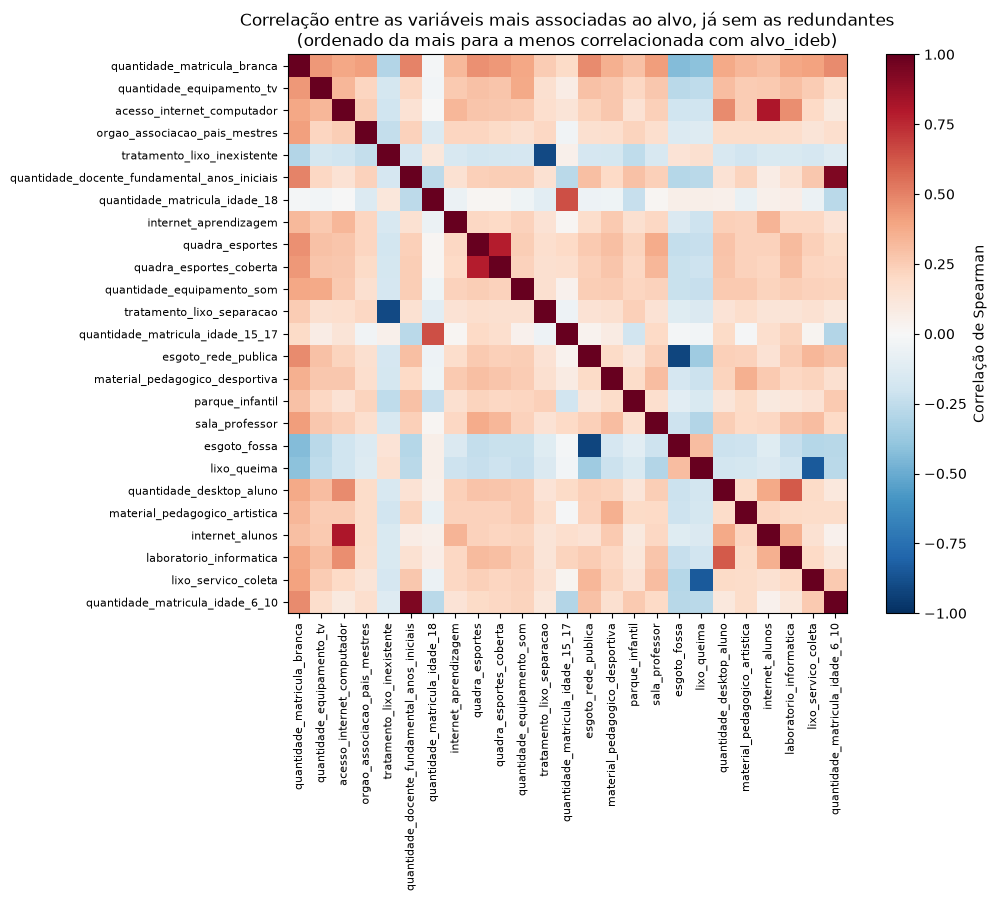

In [12]:
colunas_heatmap_final = [c for c in top_n_colunas if c in colunas_pos_redundancia][:25]
matriz_corr_final = base[colunas_heatmap_final].astype(float).corr(method="spearman")

plt.figure(figsize=(11, 9))
im = plt.imshow(matriz_corr_final.values, cmap="RdBu_r", vmin=-1, vmax=1)
plt.colorbar(im, label="Correlação de Spearman")
plt.xticks(range(len(matriz_corr_final.columns)), matriz_corr_final.columns, rotation=90, fontsize=8)
plt.yticks(range(len(matriz_corr_final.columns)), matriz_corr_final.columns, fontsize=8)
plt.title("Correlação entre as variáveis mais associadas ao alvo, já sem as redundantes\n(ordenado da mais para a menos correlacionada com alvo_ideb)")
plt.tight_layout()
plt.show()


## 8. Resolvendo a pendência do "tamanho da escola"

O notebook 07 já tinha identificado ~91 colunas de matrícula candidatas a
representar o tamanho da escola, com duas favoritas:
`quantidade_matricula_educacao_basica` (porte geral da escola, todas as etapas)
e `quantidade_matricula_fundamental_anos_iniciais` (só a etapa que o indicador
de alfabetização de fato mede). Comparo as duas diretamente aqui — preenchimento,
correlação com o alvo, e a relação entre elas — antes de decidir.


=== quantidade_matricula_educacao_basica ===
count      61357.0
mean     362.17791
std      289.67464
min            2.0
25%          155.0
50%          283.0
75%          485.0
max         4871.0
Name: quantidade_matricula_educacao_basica, dtype: Float64
% preenchido: 96.57%
Correlação (abs) com alvo_ideb: 0.072

=== quantidade_matricula_fundamental_anos_iniciais ===
count       61357.0
mean     179.455205
std      183.299263
min             0.0
25%            46.0
50%           121.0
75%           266.0
max          1719.0
Name: quantidade_matricula_fundamental_anos_iniciais, dtype: Float64
% preenchido: 96.57%
Correlação (abs) com alvo_ideb: 0.144

Em média, 'anos_iniciais' representa 53.8% de 'educacao_basica' (mediana 53.3%)


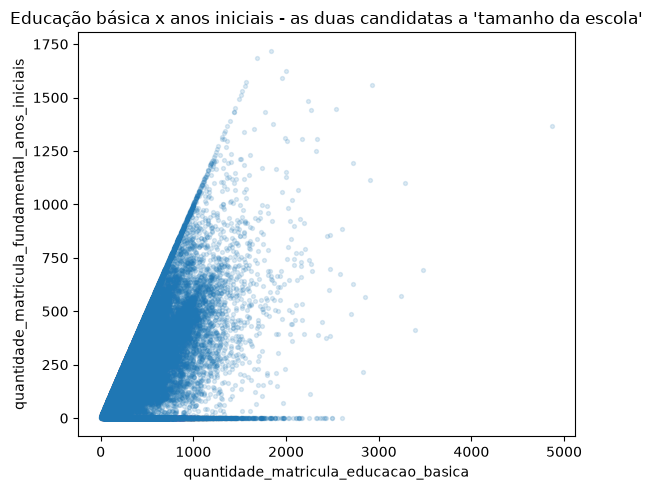

In [13]:
CANDIDATAS_TAMANHO_ESCOLA = [
    "quantidade_matricula_educacao_basica",
    "quantidade_matricula_fundamental_anos_iniciais",
]
CANDIDATAS_TAMANHO_ESCOLA = [c for c in CANDIDATAS_TAMANHO_ESCOLA if c in base.columns]

for coluna in CANDIDATAS_TAMANHO_ESCOLA:
    print(f"=== {coluna} ===")
    print(base[coluna].describe())
    print(f"% preenchido: {base[coluna].notna().mean() * 100:.2f}%")
    corr = corr_por_coluna.get(coluna, np.nan)
    print(f"Correlação (abs) com alvo_ideb: {corr}")
    print()

if len(CANDIDATAS_TAMANHO_ESCOLA) == 2:
    dados_relacao = base[CANDIDATAS_TAMANHO_ESCOLA].dropna()
    razao = (dados_relacao[CANDIDATAS_TAMANHO_ESCOLA[1]] / dados_relacao[CANDIDATAS_TAMANHO_ESCOLA[0]]).replace([np.inf, -np.inf], np.nan)
    print(f"Em média, 'anos_iniciais' representa {razao.mean() * 100:.1f}% de 'educacao_basica' (mediana {razao.median() * 100:.1f}%)")

    plt.figure(figsize=(6, 5))
    plt.scatter(dados_relacao[CANDIDATAS_TAMANHO_ESCOLA[0]], dados_relacao[CANDIDATAS_TAMANHO_ESCOLA[1]], alpha=0.15, s=8)
    plt.xlabel(CANDIDATAS_TAMANHO_ESCOLA[0])
    plt.ylabel(CANDIDATAS_TAMANHO_ESCOLA[1])
    plt.title("Educação básica x anos iniciais - as duas candidatas a 'tamanho da escola'")
    plt.tight_layout()
    plt.show()

COLUNA_TAMANHO_ESCOLA_ESCOLHIDA = "quantidade_matricula_fundamental_anos_iniciais"


**Decisão fechada:** `quantidade_matricula_fundamental_anos_iniciais` — bate
exatamente com a etapa que o IDEB dessa base mede, em vez de diluir com etapas
que não fazem parte do recorte (médio, EJA etc. dentro de `educacao_basica`).

Com essa decisão fechada, todas as outras colunas de "quantidade de alunos" que
seriam candidatas alternativas de tamanho (a começar por
`quantidade_matricula_educacao_basica`) saem do conjunto de features — não faz
sentido manter mais de uma medida de tamanho de escola, e a escolhida já
representa bem esse sinal.


In [14]:
colunas_tamanho_alternativas = [c for c in CANDIDATAS_TAMANHO_ESCOLA if c != COLUNA_TAMANHO_ESCOLA_ESCOLHIDA]
colunas_tamanho_alternativas = [c for c in colunas_tamanho_alternativas if c in colunas_pos_redundancia]

print(f"Coluna de tamanho da escola escolhida: {COLUNA_TAMANHO_ESCOLA_ESCOLHIDA}")
print(f"Colunas alternativas de tamanho removidas: {colunas_tamanho_alternativas}")

n_antes_secao_8 = len(colunas_pos_redundancia)
colunas_pos_redundancia = [c for c in colunas_pos_redundancia if c not in colunas_tamanho_alternativas]
funil_colunas["5.1 Após fechar decisão de tamanho da escola"] = len(colunas_pos_redundancia)

print(f"\nColunas reduzidas nesta etapa: {n_antes_secao_8 - len(colunas_pos_redundancia)}")
print(f"Total de candidatas após esta etapa: {len(colunas_pos_redundancia)}")


Coluna de tamanho da escola escolhida: quantidade_matricula_fundamental_anos_iniciais
Colunas alternativas de tamanho removidas: ['quantidade_matricula_educacao_basica']

Colunas reduzidas nesta etapa: 1
Total de candidatas após esta etapa: 216


## 9. Tratamento de `quantidade_matricula_branca` — o ponto ético (Achado 19)

Recapitulando o que já registrei no notebook 07 e em `reports/decisoes.md`
(Achado 19): `quantidade_matricula_branca` foi a variável de maior correlação
absoluta com `ideb` de toda a base (0,403) — mais forte que qualquer variável de
infraestrutura. Isso não é uma relação causal (a cor da pele do aluno não "causa"
desempenho) — é reflexo de um padrão bem documentado no Brasil: composição racial
da escola correlaciona com contexto socioeconômico e desigualdade histórica
regional/urbana, que por sua vez afeta desempenho medido.

Uso esse recorte pra listar as opções, com prós e contras, mas não decido
sozinho — é uma decisão de projeto, não uma conclusão técnica:

1. **Excluir totalmente** a variável (e as demais quebras de raça/cor) do
   conjunto de features. Mais seguro eticamente, mas descarta um sinal real que
   pode ter poder preditivo genuíno (mesmo que via um mecanismo indesejável).
2. **Manter como feature**, documentando explicitamente o risco de o modelo
   aprender um proxy racial em vez de fatores acionáveis (infraestrutura, corpo
   docente) — e reportando isso como limitação do modelo no relatório final.
3. **Manter só a versão em proporção** (`quantidade_matricula_branca` dividido
   pelo tamanho da escola, ver Seção 10) em vez da contagem bruta, o que ao menos
   remove a parte do sinal que é só "escola grande = mais aluno branco em
   número absoluto" — mas não resolve o proxy socioeconômico de fundo.

**Decisão fechada: opção 1 — excluir totalmente** as colunas de raça/cor do
conjunto de features.

**Por que registro isso com tanto destaque:** um modelo treinado com dado
histórico real não aprende só "o que causa desempenho" — ele aprende **qualquer
padrão estatístico presente nos dados**, incluindo desigualdades estruturais e
preconceitos que já existem na sociedade e ficam refletidos nas variáveis
disponíveis. Se eu deixasse `quantidade_matricula_branca` como feature, o modelo
poderia acabar usando composição racial da escola como atalho pra prever
desempenho, em vez de aprender os fatores realmente acionáveis por política
pública (infraestrutura, corpo docente, recursos). Isso não seria só uma escolha
técnica ruim — seria o modelo reproduzindo e, na prática, validando
estatisticamente um viés que já existe no sistema educacional. Excluir essa
variável (e as demais quebras de raça/cor) é a forma mais direta de reduzir esse
risco, mesmo custando um pouco de poder preditivo bruto. Documento essa decisão
e o risco de viés residual (a composição racial ainda pode vazar indiretamente
via outras variáveis correlacionadas, como localização/região) como limitação
explícita do modelo no relatório final.


In [15]:
# Decisão fechada (ver célula acima) - opção 1: excluir.
INCLUIR_MATRICULA_BRANCA_COMO_FEATURE = False

COLUNAS_RACA_COR = [c for c in colunas_pos_redundancia if classificacao.get(c) == "quantidade_matricula" and any(
    sufixo in c for sufixo in ["_branca", "_preta", "_parda", "_amarela", "_indigena"]
)]
print(f"Colunas de raça/cor encontradas na base: {COLUNAS_RACA_COR}")

if not INCLUIR_MATRICULA_BRANCA_COMO_FEATURE:
    colunas_pos_etica = [c for c in colunas_pos_redundancia if c not in COLUNAS_RACA_COR]
    print(f"\nExcluindo {len(COLUNAS_RACA_COR)} colunas de raça/cor do conjunto de features (opção 1, padrão conservador).")
else:
    colunas_pos_etica = colunas_pos_redundancia
    print("\nMantendo colunas de raça/cor como feature - documentar a decisão e o risco de proxy no relatório final.")

funil_colunas["6. Após decisão ética (raça/cor)"] = len(colunas_pos_etica)


Colunas de raça/cor encontradas na base: ['quantidade_matricula_branca', 'quantidade_matricula_preta', 'quantidade_matricula_parda', 'quantidade_matricula_amarela', 'quantidade_matricula_indigena']

Excluindo 5 colunas de raça/cor do conjunto de features (opção 1, padrão conservador).


## 10. Convertendo contagens brutas em proporções — só onde valer a pena

Cheguei a considerar converter *toda* contagem de subgrupo (sexo, raça, idade,
zona, turno) em proporção sobre o tamanho da escola — mas, revendo com calma,
a maioria dessas quebras é informação redundante demais pra valer a pena manter
(são exatamente as famílias "complementares" da Seção 7.1: sexo, raça/cor, idade,
zona, turno). Manter todas como proporção só trocaria "muitas contagens
redundantes" por "muitas proporções redundantes" — não resolve o problema de
dimensionalidade, só disfarça.

**Decisão fechada:** ignoro a conversão em massa. Só calculo e mantenho a
proporção de uma coluna quando ela passa em três critérios ao mesmo tempo: (1)
já apareceu com correlação relevante contra o alvo na Seção 6, (2) tem boa
presença na base (preenchimento alto, não é um recorte raro de poucas escolas), e
(3) tem variância genuína entre escolas (não é quase-constante). Só nesse caso a
proporção tem chance real de carregar sinal novo que valha o espaço extra no
conjunto de features.

Confirmo também, antes de seguir, que o filtro de etapa é consistente com o
alvo: o `alvo_ideb` desta base vem do recorte `anos_escolares == "iniciais (1-5)"`
em `montar_base_escola_silver()` — ou seja, é o IDEB dos **anos iniciais do
fundamental**, não do ensino médio. Faz sentido, então, olhar só as colunas de
matrícula relacionadas a "anos iniciais" como candidatas de composição, e não a
etapas fora desse recorte (médio, EJA — já excluída na Seção 5.1).


In [16]:
# confirmação: o recorte do alvo é mesmo fundamental/anos iniciais, não médio
print("Valores distintos de 'anos_escolares' usados no filtro da base silver: iniciais (1-5)")
print("(ver src/preprocessing/build_base_escola.py, linha do filtro de ideb_filtrado)")

# só colunas de matrícula que têm a ver com "anos iniciais" entram como
# candidatas a composição - o resto (outras etapas) já não faz sentido aqui
colunas_matricula_restantes = [c for c in colunas_pos_etica if classificacao.get(c) == "quantidade_matricula"]
colunas_matricula_anos_iniciais = [c for c in colunas_matricula_restantes if "anos_iniciais" in c or c == COLUNA_TAMANHO_ESCOLA_ESCOLHIDA]
colunas_matricula_outras_etapas = [c for c in colunas_matricula_restantes if c not in colunas_matricula_anos_iniciais]

print(f"\nColunas de matrícula restantes no funil: {len(colunas_matricula_restantes)}")
print(f"  - relacionadas a 'anos iniciais' (candidatas a composição): {colunas_matricula_anos_iniciais}")
print(f"  - de outras etapas/quebras (sexo, raça, idade, zona, turno etc. - candidatas a ignorar): {len(colunas_matricula_outras_etapas)}")


Valores distintos de 'anos_escolares' usados no filtro da base silver: iniciais (1-5)
(ver src/preprocessing/build_base_escola.py, linha do filtro de ideb_filtrado)

Colunas de matrícula restantes no funil: 51
  - relacionadas a 'anos iniciais' (candidatas a composição): ['quantidade_matricula_fundamental_anos_iniciais', 'quantidade_matricula_fundamental_anos_iniciais_integral']
  - de outras etapas/quebras (sexo, raça, idade, zona, turno etc. - candidatas a ignorar): 49


In [17]:
LIMIAR_CORRELACAO_PARA_PROPORCAO = 0.15
LIMIAR_PREENCHIMENTO_PARA_PROPORCAO = 0.9
LIMIAR_VARIANCIA_PARA_PROPORCAO = 0.90  # menos concentrada que o corte geral da Seção 5

candidatas_proporcao_valiosa = []
for coluna in colunas_matricula_outras_etapas:
    abs_corr = corr_por_coluna.get(coluna, 0)
    pct_preenchido = base[coluna].notna().mean()
    prop_dominante_col = proporcao_valor_mais_frequente(base[coluna])
    if abs_corr >= LIMIAR_CORRELACAO_PARA_PROPORCAO and pct_preenchido >= LIMIAR_PREENCHIMENTO_PARA_PROPORCAO and prop_dominante_col <= LIMIAR_VARIANCIA_PARA_PROPORCAO:
        candidatas_proporcao_valiosa.append(coluna)

print(f"Colunas que passaram nos três critérios (correlação + presença + variância) - candidatas a virar proporção: {len(candidatas_proporcao_valiosa)}")
print(candidatas_proporcao_valiosa)

mapa_contagem_para_proporcao = {}
for coluna in candidatas_proporcao_valiosa:
    nome_proporcao = f"proporcao_{coluna.replace('quantidade_matricula_', '')}"
    base[nome_proporcao] = base[coluna] / base[COLUNA_TAMANHO_ESCOLA_ESCOLHIDA].replace(0, np.nan)
    mapa_contagem_para_proporcao[coluna] = nome_proporcao

if mapa_contagem_para_proporcao:
    comparacao_transformacao = []
    for coluna, nome_proporcao in mapa_contagem_para_proporcao.items():
        sub_bruta = base[[coluna, "alvo_ideb"]].dropna()
        sub_prop = base[[nome_proporcao, "alvo_ideb"]].dropna()
        comparacao_transformacao.append({
            "coluna_original": coluna,
            "corr_contagem_bruta": round(sub_bruta[coluna].astype(float).corr(sub_bruta["alvo_ideb"].astype(float), method="spearman"), 3),
            "corr_proporcao": round(sub_prop[nome_proporcao].astype(float).corr(sub_prop["alvo_ideb"].astype(float), method="spearman"), 3),
        })
    print("\nComparação correlação: contagem bruta x proporção")
    print(pd.DataFrame(comparacao_transformacao).to_string(index=False))
else:
    print("\nNenhuma coluna passou nos três critérios - não crio nenhuma proporção nesta rodada.")

# as demais quebras (sexo, raça já tratada na Seção 9, idade, zona, turno que não
# passaram nos critérios acima) saem do conjunto - são redundantes com o tamanho
# da escola e/ou fracas demais pra justificar o espaço extra.
colunas_matricula_a_remover = [c for c in colunas_matricula_outras_etapas if c not in candidatas_proporcao_valiosa]
colunas_pos_proporcao = [c for c in colunas_pos_etica if c not in colunas_matricula_a_remover]
colunas_pos_proporcao += list(mapa_contagem_para_proporcao.values())
funil_colunas["7. Após decisão de composição (proporção só onde vale a pena)"] = len(colunas_pos_proporcao)
print(f"\nColunas de matrícula removidas nesta etapa (redundantes/fracas): {len(colunas_matricula_a_remover)}")
print(f"Total de candidatas após esta etapa: {len(colunas_pos_proporcao)}")


Colunas que passaram nos três critérios (correlação + presença + variância) - candidatas a virar proporção: 7
['quantidade_desktop_aluno', 'quantidade_computador_portatil_aluno', 'quantidade_matricula_fundamental_1_ano', 'quantidade_matricula_fundamental_2_ano', 'quantidade_matricula_idade_6_10', 'quantidade_matricula_idade_15_17', 'quantidade_matricula_idade_18']

Comparação correlação: contagem bruta x proporção
                       coluna_original  corr_contagem_bruta  corr_proporcao
              quantidade_desktop_aluno                0.179           0.156
  quantidade_computador_portatil_aluno                0.169           0.151
quantidade_matricula_fundamental_1_ano                0.159           0.095
quantidade_matricula_fundamental_2_ano                0.154           0.065
       quantidade_matricula_idade_6_10                0.172           0.324
      quantidade_matricula_idade_15_17               -0.192          -0.211
         quantidade_matricula_idade_18            

## 11. Variáveis categóricas — plano de encoding

Sigo aqui o material do `IAS_Feature_enge.ipynb` do professor: para colunas
nominais de baixa cardinalidade sem ordem natural (`sigla_uf`, `tipo_localizacao`,
`tipo_regulamentacao`, etc.), o próprio notebook do curso recomenda One-Hot
Encoding via `OneHotEncoder` dentro de um `ColumnTransformer` — é a técnica mais
segura quando não existe uma ordem implícita entre as categorias (ao contrário de
Label Encoding, que introduziria uma ordem falsa).

**O que quebrou na primeira tentativa (e por quê):** tentei separar categórica de
numérica usando a heurística de cardinalidade (`nunique <= 15`), igual fiz na
Seção 7.1 do notebook 07 — mas contra a base real isso não funciona bem aqui:
várias colunas de **contagem** (`quantidade_profissional_*`, `quantidade_docente_*`
etc.) têm poucos valores distintos só porque a contagem em si costuma ser baixa
(a maioria das escolas tem 0 a 10 profissionais de um tipo raro), então a
heurística classifica contagem como categórica por acidente. Tentei então usar só
o `dtype`, mas na base real **praticamente toda coluna vem como numérica** (até
os códigos de tipo, como `tipo_localizacao`, estavam armazenados como texto
representando float, tipo `"1.0"`) — então dtype sozinho não separa nada. Cheguei
a classificar manualmente por prefixo de nome (`tipo_`) como solução provisória —
mas isso mudou: agora tenho o dicionário oficial de código→texto, e a tradução em
si já vem pronta na base (Seção 11.0), então a classificação deixa de ser um
proxy e passa a ser exata (Seção 11.1).


### 11.0 Dicionário oficial de tradução dos códigos — tradução já aplicada no pré-processamento

Pedi a ingestão da tabela `dicionario` do `br_inep_censo_escolar`
(`s3://.../bronze/br_inep_censo_escolar/dicionario/`), do mesmo jeito que o
dataset de alfabetização já tinha uma (`br_inep_avaliacao_alfabetizacao.dicionario`),
e testei a cobertura real dela contra os códigos que aparecem em `escola_completo`
antes de confiar nela (documentado no Achado 26 de `reports/decisoes.md`).

**Diferença em relação à primeira versão deste notebook:** antes, a tradução
(`traduzir_categoricas_escola`) rodava aqui dentro, célula a célula. Agora ela
faz parte do pré-processamento (`ler_base_escola_modelo()`, Seção 1) — a `base`
que uso a partir daqui já chega com os códigos traduzidos pra texto. Não repito
o teste de cobertura aqui pra não duplicar lógica (já foi feito uma vez ao
validar a função, Achado 26); só recupero a lista de colunas que o dicionário
documenta, pra separar categórica de numérica na próxima seção.


In [18]:
dicionario_escola = ler_dicionario_escola()
colunas_categoricas_dicionario = colunas_categoricas_com_dicionario(dicionario_escola)
print(f"Colunas com tradução oficial (já aplicada em src/preprocessing/build_base_escola.py): {colunas_categoricas_dicionario}")


Lendo dicionario_escola do cache local: C:\Users\wesle\dev\ai-scientist-tech-challenge-3-modeling\data\processed\dicionario_escola.parquet
Colunas com tradução oficial (já aplicada em src/preprocessing/build_base_escola.py): ['rede', 'tipo_aee', 'tipo_atividade_complementar', 'tipo_categoria_escola_privada', 'tipo_convenio_poder_publico', 'tipo_lingua_indigena', 'tipo_local_funcionamento_galpao', 'tipo_local_funcionamento_predio_escolar', 'tipo_localizacao', 'tipo_localizacao_diferenciada', 'tipo_proposta_pedagogica', 'tipo_rede_local', 'tipo_regulamentacao', 'tipo_responsavel_regulamentacao', 'tipo_situacao_funcionamento']


### 11.1 Classificação categórica x numérica — dtype volta a funcionar, agora que a tradução já rodou antes

Achado 24 tinha descartado o `dtype` como sinal de categórica x numérica, porque
na base bruta praticamente toda coluna (até os códigos de tipo) vinha como
número. Isso muda agora que a tradução já aconteceu **antes** desta seção, no
pré-processamento (Seção 1): toda coluna que o dicionário documenta virou texto,
e o `dtype` volta a ser um sinal confiável — uso `is_numeric_dtype` em vez de
depender só da lista do dicionário.

Isso também resolve um caso que a lista do dicionário sozinha não cobria:
`sigla_uf` (decisão fechada em `reports/decisoes.md` — entra como feature) é
texto (sigla do estado), mas **não é uma coluna que o dicionário de
`escola_completo` documenta** (ela vem do lado do IDEB, não é um código do
Censo) — então checar só `colunas_categoricas_dicionario` deixaria `sigla_uf`
cair no balde "numérica" por engano e quebraria o `SimpleImputer` de mediana
(erro real que apareceu testando contra a base real: `could not convert string
to float: 'PA'`). Usar o `dtype` em vez da lista do dicionário resolve os dois
casos com a mesma regra. As flags binárias de infraestrutura (0/1, ex.
`agua_potavel`, `biblioteca`) continuam **numéricas passthrough**: one-hot de
uma variável de 2 categorias é redundante com usar o 0/1 direto.

Mantenho também a lista de "candidatas a revisar manualmente" (baixa
cardinalidade dentro das numéricas) — colunas de contagem com poucos valores
distintos só por acidente (ex. `quantidade_profissional_nutricionista`), não
código categórico disfarçado (Achado 24) — mas prefiro ver essa lista
explicitamente a cada execução do que presumir que não tem nada ali.


In [19]:
colunas_categoricas_final = [c for c in colunas_pos_proporcao if not pd.api.types.is_numeric_dtype(base[c])]
colunas_numericas_final = [c for c in colunas_pos_proporcao if c not in colunas_categoricas_final]

print(f"Candidatas finais: {len(colunas_pos_proporcao)}")
print(f"  - categóricas (dtype não numérico, vão para OneHotEncoder): {len(colunas_categoricas_final)}")
print(f"  - numéricas/binárias passthrough: {len(colunas_numericas_final)}")
print(f"\nColunas categóricas identificadas: {colunas_categoricas_final}")

# conferência: alguma categórica documentada pelo dicionário ficou de fora
# (não deveria acontecer, já que a tradução roda antes - ver Seção 1) -
# ajuda a pegar cedo se algum dia a tradução parar de rodar como esperado.
categoricas_dicionario_nao_traduzidas = [
    c for c in colunas_categoricas_dicionario
    if c in colunas_pos_proporcao and c in colunas_numericas_final
]
if categoricas_dicionario_nao_traduzidas:
    print(f"\n⚠️  ATENÇÃO: colunas do dicionário que não vieram traduzidas: {categoricas_dicionario_nao_traduzidas}")

# lista de revisão manual: baixa cardinalidade dentro das numéricas
candidatas_revisar_manualmente = [
    c for c in colunas_numericas_final
    if 3 <= base[c].nunique(dropna=True) <= 15
]
print(f"\nCandidatas a revisar manualmente (cardinalidade 3-15, dtype numérico): {len(candidatas_revisar_manualmente)}")
print(candidatas_revisar_manualmente)
print("Se alguma dessas for código categórico sem entrada no dicionário, mover pra")
print("colunas_categoricas_final antes de fechar o pipeline.py.")


Candidatas finais: 176
  - categóricas (dtype não numérico, vão para OneHotEncoder): 10
  - numéricas/binárias passthrough: 166

Colunas categóricas identificadas: ['sigla_uf', 'tipo_localizacao', 'tipo_localizacao_diferenciada', 'tipo_regulamentacao', 'tipo_responsavel_regulamentacao', 'tipo_local_funcionamento_predio_escolar', 'tipo_rede_local', 'tipo_proposta_pedagogica', 'tipo_aee', 'tipo_atividade_complementar']

Candidatas a revisar manualmente (cardinalidade 3-15, dtype numérico): 12
['tratamento_lixo_separacao', 'tratamento_lixo_reciclagem', 'tratamento_lixo_inexistente', 'acesso_internet_computador', 'acesso_internet_dispositivo_pessoal', 'quantidade_profissional_nutricionista', 'quantidade_profissional_psicologo', 'quantidade_profissional_gestao', 'quantidade_profissional_assistente_social', 'redes_sociais', 'espaco_atividade_comunidade', 'espaco_equipamento_alunos']
Se alguma dessas for código categórico sem entrada no dicionário, mover pra
colunas_categoricas_final antes de

### 11.2 Montando o `ColumnTransformer` + `Pipeline`

Correção em relação à primeira versão: em vez de imputar o código numérico bruto
com um sentinela (`-1`) e só então fazer o One-Hot — o que deixaria os nomes de
feature ilegíveis (tipo `tipo_regulamentacao_2.0`) e não bate com o que o texto
desta seção sempre disse que ia fazer — o código já chega traduzido pra texto
oficial (Seção 1, via `ler_base_escola_modelo()`), então não preciso mais chamar
`traduzir_categoricas_escola` aqui dentro. A tradução já resolve o nulo (vira a
string `"desconhecido"`) e qualquer código sem entrada no dicionário fica visível
como `"codigo_nao_documentado_<código>"`, em vez de quebrar ou sumir. Mantenho um
`SimpleImputer(strategy="constant", fill_value="desconhecido")` no pipeline
categórico só como rede de segurança (mesmo tipo — string —, não mais o `-1`
numérico que não batia com o que o texto prometia).


In [20]:
# conferência rápida: nenhuma coluna categórica final deveria sobrar como NaN
# de verdade (nulo já virou a string "desconhecido" no pré-processamento)
for coluna in colunas_categoricas_final:
    print(f"{coluna}: {base[coluna].nunique()} categorias -> {sorted(base[coluna].unique())[:6]}...")

preprocessador_exemplo = ColumnTransformer(
    transformers=[
        ("numericas", SimpleImputer(strategy="median"), colunas_numericas_final),
        ("categoricas", Pipeline([
            ("imputer", SimpleImputer(strategy="constant", fill_value="desconhecido")),
            ("onehot", OneHotEncoder(handle_unknown="ignore")),
        ]), colunas_categoricas_final),
    ],
    remainder="drop",
)

X_exemplo = base[colunas_numericas_final + colunas_categoricas_final]
y_exemplo = base["alvo_ideb"]
mascara_alvo_valido = y_exemplo.notna()

X_transformado = preprocessador_exemplo.fit_transform(X_exemplo[mascara_alvo_valido])
print(f"\nShape depois do ColumnTransformer de exemplo: {X_transformado.shape}")


sigla_uf: 27 categorias -> ['AC', 'AL', 'AM', 'AP', 'BA', 'CE']...
tipo_localizacao: 2 categorias -> ['Rural', 'Urbana']...
tipo_localizacao_diferenciada: 6 categorias -> ['A escola não está em área de localização diferenciada', 'Terra indígena', 'codigo_nao_documentado_0', 'codigo_nao_documentado_8', 'desconhecido', 'Área de assentamento']...
tipo_regulamentacao: 4 categorias -> ['Em tramitação', 'Não', 'Sim', 'desconhecido']...
tipo_responsavel_regulamentacao: 6 categorias -> ['Estadual', 'Estadual e Municipal', 'Federal', 'Federal e Estadual', 'Municipal', 'desconhecido']...
tipo_local_funcionamento_predio_escolar: 4 categorias -> ['Alugado', 'Cedido', 'Próprio', 'desconhecido']...
tipo_rede_local: 6 categorias -> ['A cabo', 'A cabo e Wireless', 'Não há rede local interligando computadores', 'Não informado', 'Wireless', 'desconhecido']...
tipo_proposta_pedagogica: 5 categorias -> ['A escola não possui projeto político pedagógico/proposta pedagógica', 'Não', 'Não informado', 'Sim', '

## 12. Importância de features via um modelo-base (extensão além do que o curso mostrou)

**Nota sobre o que vem do curso e o que eu adicionei:** os notebooks do professor
(`IAS_Classificacao.ipynb`, `IAS_Regressao.ipynb`) não trazem nenhuma técnica de
redução de dimensionalidade — nem correlação-filtro, nem VIF, nem seleção via
qui-quadrado/mutual information, nem PCA. As Seções 4 a 11 deste notebook (nulos,
baixa variância, correlação, multicolinearidade, encoding) já cobrem o que faz
sentido tecnicamente, seguindo o padrão de correlação de Spearman que eu mesmo
já vinha usando desde o notebook 07. Esta seção acrescenta mais uma lente,
complementar à correlação: a **importância de features de um modelo baseado em
árvore** (`RandomForestClassifier`, no mesmo espírito do `RandomForestRegressor`
que o curso usa em `IAS_Regressao.ipynb`, só que aqui pra classificação). A
vantagem sobre a correlação de Spearman é que a árvore captura interação e
relação não-linear entre variáveis, que uma correlação par-a-par não vê.

Isso é só um diagnóstico — treino um modelo simples e descartável só pra olhar
`feature_importances_`, não é o modelo final do projeto (esse vem no Dia 4, com
a base já dividida em treino/validação/teste do jeito certo, com `GroupShuffleSplit`
— ver checklist no fim deste notebook).


In [21]:
X_diagnostico = base[colunas_numericas_final + colunas_categoricas_final][mascara_alvo_valido]
y_diagnostico = base.loc[mascara_alvo_valido, "alvo_ideb"].astype(int)

X_treino_diag, X_val_diag, y_treino_diag, y_val_diag = train_test_split(
    X_diagnostico, y_diagnostico, test_size=0.2, random_state=42, stratify=y_diagnostico,
)

pipeline_diagnostico = Pipeline([
    ("prep", preprocessador_exemplo),
    ("modelo", RandomForestClassifier(n_estimators=300, max_depth=8, random_state=42, n_jobs=-1)),
])
pipeline_diagnostico.fit(X_treino_diag, y_treino_diag)

print(f"Acurácia na validação (só diagnóstico, não é o modelo final): {pipeline_diagnostico.score(X_val_diag, y_val_diag):.3f}")

# uso o get_feature_names_out do próprio ColumnTransformer em vez de montar o
# nome na mão - mais robusto a mudanças na composição das colunas categóricas
nomes_features_diagnostico = list(pipeline_diagnostico.named_steps["prep"].get_feature_names_out())
importancias = pipeline_diagnostico.named_steps["modelo"].feature_importances_

tabela_importancia = pd.DataFrame({
    "feature": nomes_features_diagnostico,
    "importancia": importancias,
}).sort_values("importancia", ascending=False)

print("\n=== Top 20 features por importância (RandomForest) ===")
print(tabela_importancia.head(20).to_string(index=False))


Acurácia na validação (só diagnóstico, não é o modelo final): 0.746

=== Top 20 features por importância (RandomForest) ===
                                                feature  importancia
                        numericas__proporcao_idade_6_10     0.121099
                  numericas__acesso_internet_computador     0.047256
                       numericas__proporcao_idade_15_17     0.045869
                               categoricas__sigla_uf_BA     0.039350
                          numericas__proporcao_idade_18     0.035755
            numericas__quantidade_matricula_idade_15_17     0.032475
               numericas__quantidade_matricula_idade_18     0.029823
                 numericas__tratamento_lixo_inexistente     0.029758
                   numericas__quantidade_equipamento_tv     0.028697
               numericas__orgao_associacao_pais_mestres     0.026768
                               categoricas__sigla_uf_SP     0.021761
                               categoricas__sigl

### 12.1 Visualizando a importância das features


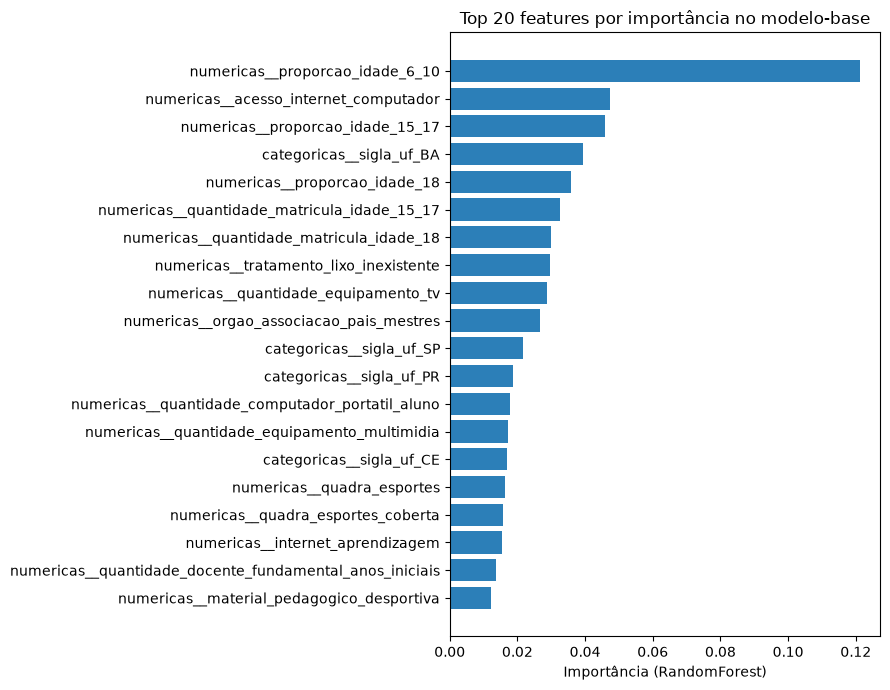

In [22]:
top_20_importancia = tabela_importancia.head(20)

plt.figure(figsize=(9, 7))
plt.barh(top_20_importancia["feature"], top_20_importancia["importancia"], color="#2c7fb8")
plt.xlabel("Importância (RandomForest)")
plt.title("Top 20 features por importância no modelo-base")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


## 13. O funil completo de redução de dimensionalidade

Visualização final: quanto cada etapa reduziu o conjunto de colunas, das 455
originais até o conjunto final de candidatas a feature.


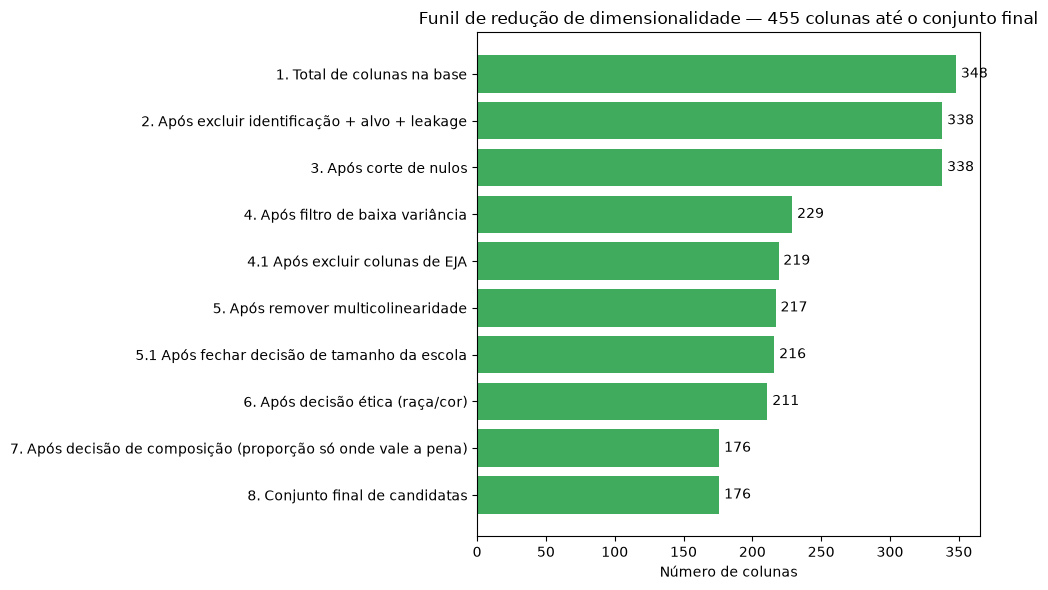

Resumo do funil:
  1. Total de colunas na base: 348
  2. Após excluir identificação + alvo + leakage: 338
  3. Após corte de nulos: 338
  4. Após filtro de baixa variância: 229
  4.1 Após excluir colunas de EJA: 219
  5. Após remover multicolinearidade: 217
  5.1 Após fechar decisão de tamanho da escola: 216
  6. Após decisão ética (raça/cor): 211
  7. Após decisão de composição (proporção só onde vale a pena): 176
  8. Conjunto final de candidatas: 176


In [23]:
funil_colunas["8. Conjunto final de candidatas"] = len(colunas_pos_proporcao)

etapas = list(funil_colunas.keys())
valores = list(funil_colunas.values())

plt.figure(figsize=(10, 6))
barras = plt.barh(etapas, valores, color="#41ab5d")
plt.xlabel("Número de colunas")
plt.title("Funil de redução de dimensionalidade — 455 colunas até o conjunto final")
plt.gca().invert_yaxis()
for barra, valor in zip(barras, valores):
    plt.text(valor + max(valores) * 0.01, barra.get_y() + barra.get_height() / 2, f"{valor}", va="center")
plt.tight_layout()
plt.show()

print("Resumo do funil:")
for etapa, valor in funil_colunas.items():
    print(f"  {etapa}: {valor}")


## 14. Classificação temática — antes x depois da seleção

Fecho com a mesma tabela da Seção 2 (colunas por grupo temático), agora só com o
conjunto final de candidatas — é a evidência mais direta de quanto reduzi e onde
concentrei o corte por grupo. Gero as duas tabelas lado a lado e salvo a versão
"depois" ao lado da versão "antes" (Seção 2), como referência pro relatório
final.


In [24]:
classificacao_final = {c: classificacao.get(c, "nao_classificada") for c in colunas_pos_proporcao}
resumo_classificacao_final = pd.Series(classificacao_final).value_counts()

comparacao_antes_depois = pd.DataFrame({
    "antes": resumo_classificacao_inicial,
    "depois": resumo_classificacao_final,
}).fillna(0).astype(int)
comparacao_antes_depois["reducao_pct"] = (
    (comparacao_antes_depois["antes"] - comparacao_antes_depois["depois"]) / comparacao_antes_depois["antes"] * 100
).round(1)
comparacao_antes_depois = comparacao_antes_depois.sort_values("antes", ascending=False)

print("Classificação temática - antes x depois da seleção de features:")
print(comparacao_antes_depois.to_string())

resumo_classificacao_final.rename("quantidade_colunas").to_csv(
    PASTA_REFERENCIAS / "classificacao_colunas_depois_selecao.csv"
)
comparacao_antes_depois.to_csv(PASTA_REFERENCIAS / "comparacao_antes_depois_selecao_features.csv")
print(f"\nTabelas salvas em {PASTA_REFERENCIAS}/ (referência pro relatório final).")


Classificação temática - antes x depois da seleção de features:
                              antes  depois  reducao_pct
infraestrutura                  130      88         32.3
quantidade_matricula             88       9         89.8
corpo_tecnico_administrativo     29      23         20.7
quantidade_turma                 26      16         38.5
corpo_docente                    17      10         41.2
nao_classificada                 16      13         18.8
modalidade_etapa                 14       4         71.4
gestao_administrativa            10       7         30.0
identificacao                     5       3         40.0
localizacao                       3       3          0.0

Tabelas salvas em ..\..\reports\referencias/ (referência pro relatório final).


## 14.1 Features finais organizadas por tipo — pra eu validar grupo a grupo

Quero levar pra modelagem o menor número de features possível, e as mais
generalistas dentro de cada tema — em vez de decidir isso sozinho aqui dentro do
notebook, monto uma tabela com o conjunto final que sobrou no funil
(`colunas_pos_proporcao`), organizada por grupo temático, com o tipo (categórica
x numérica), a correlação com `alvo_ideb` (quando é uma coluna numérica - Seção
6) e o percentual de preenchimento. Reviso essa tabela grupo a grupo antes de
fechar a lista definitiva em `src/preprocessing/pipeline.py` — dentro de cada
grupo, a ideia é manter só as colunas mais gerais e com sinal mais claro,
descartando variantes redundantes do mesmo fenômeno (mesmo espírito das famílias
de matrícula da Seção 7.1, agora aplicado a todo o conjunto final).

**Ajuste feito depois de bater o olho no CSV pela primeira vez:** a versão
original só trazia `corr_alvo_ideb` (só preenchida pras numéricas) e
`pct_preenchido` — não dava pra saber, batendo o olho na linha de uma
categórica, "o que tem" nela. Agora reuso a `simple_eda()` (a mesma função
que usei pra achar o bug de tradução do Achado 31) pra trazer, na mesma
tabela:

- pras **numéricas**: média, mediana, mínimo e máximo (Achado 32);
- pras **categóricas**: os `N_TOP_CATEGORIAS` valores mais frequentes, com
  contagem — e, como a `simple_eda` é genérica e não sabe o que é "ideb", eu
  calculo aqui em cima o `ideb_medio` de cada um desses valores, que é
  basicamente o mesmo cruzamento que fiz na mão no notebook 07 (Seção 6/7)
  pra achar o bug de tradução, só que agora automático pra qualquer
  categórica do funil.

Todas essas estatísticas usam só as escolas com `ideb` preenchido
(`mascara_ideb_existe` abaixo) — não faz sentido descrever a distribuição de
uma feature usando escolas que nem entram no treino/teste por falta de
rótulo. Mantive as colunas que já existiam (`grupo`, `coluna`, `tipo`,
`corr_alvo_ideb`, `pct_preenchido`) porque ajudaram na primeira revisão.


In [25]:
mapa_corr_alvo = tabela_correlacao.set_index("coluna")["corr_alvo_ideb"].to_dict()

# Restrinjo a EDA agrupada abaixo às escolas com ideb preenchido - é a
# população que de fato entra no treino/teste, então é ela que eu quero
# descrever aqui (não faz sentido, por ex., que a média de uma feature
# inclua escolas sem rótulo que nunca vão ser usadas).
mascara_ideb_existe = base["ideb"].notna()
base_com_ideb = base.loc[mascara_ideb_existe]
print(f"EDA agrupada abaixo usa só as {mascara_ideb_existe.sum()} escolas com "
      f"ideb preenchido ({mascara_ideb_existe.mean() * 100:.1f}% do total de "
      f"{len(base)}).")

N_TOP_CATEGORIAS = 3
eda_funil = simple_eda(base_com_ideb, top_n_categorias=N_TOP_CATEGORIAS, colunas=colunas_pos_proporcao)
eda_numericas = eda_funil["numericas"]
eda_categoricas = eda_funil["categoricas"]

linhas_revisao = []
for coluna in colunas_pos_proporcao:
    tipo_coluna = "categórica" if coluna in colunas_categoricas_final else "numérica"
    linha = {
        "grupo": classificacao.get(coluna, "nao_classificada"),
        "coluna": coluna,
        "tipo": tipo_coluna,
        "corr_alvo_ideb": mapa_corr_alvo.get(coluna, np.nan),
        "pct_preenchido": round(base[coluna].notna().mean() * 100, 2),
        "media": np.nan,
        "mediana": np.nan,
        "minimo": np.nan,
        "maximo": np.nan,
    }
    for i in range(1, N_TOP_CATEGORIAS + 1):
        linha[f"top_{i}_valor"] = None
        linha[f"top_{i}_contagem"] = None
        linha[f"top_{i}_ideb_medio"] = np.nan

    if tipo_coluna == "numérica" and coluna in eda_numericas.index:
        linha["media"] = eda_numericas.loc[coluna, "media"]
        linha["mediana"] = eda_numericas.loc[coluna, "mediana"]
        linha["minimo"] = eda_numericas.loc[coluna, "minimo"]
        linha["maximo"] = eda_numericas.loc[coluna, "maximo"]
    elif coluna in eda_categoricas.index:
        serie = base_com_ideb[coluna]
        for i in range(1, N_TOP_CATEGORIAS + 1):
            valor = eda_categoricas.loc[coluna, f"top_{i}_valor"]
            contagem = eda_categoricas.loc[coluna, f"top_{i}_contagem"]
            linha[f"top_{i}_valor"] = valor
            linha[f"top_{i}_contagem"] = contagem
            if pd.notna(valor):
                linha[f"top_{i}_ideb_medio"] = round(base_com_ideb.loc[serie == valor, "ideb"].mean(), 2)

    linhas_revisao.append(linha)

tabela_revisao_por_tipo = pd.DataFrame(linhas_revisao)
tabela_revisao_por_tipo["abs_corr"] = tabela_revisao_por_tipo["corr_alvo_ideb"].abs()
tabela_revisao_por_tipo = tabela_revisao_por_tipo.sort_values(["grupo", "abs_corr"], ascending=[True, False])

colunas_resumo_print = [
    "coluna", "tipo", "corr_alvo_ideb", "pct_preenchido",
    "media", "mediana", "minimo", "maximo",
    "top_1_valor", "top_1_contagem", "top_1_ideb_medio",
]
for grupo, tabela_grupo in tabela_revisao_por_tipo.groupby("grupo", sort=False):
    print(f"\n=== {grupo} ({len(tabela_grupo)} colunas) ===")
    print(tabela_grupo[colunas_resumo_print].to_string(index=False))

tabela_revisao_por_tipo.to_csv(PASTA_REFERENCIAS / "features_finais_por_tipo_para_revisao.csv", index=False)
print(f"\nTabela salva em {PASTA_REFERENCIAS / 'features_finais_por_tipo_para_revisao.csv'} - reviso grupo a grupo antes de fechar a lista final.")
print("Colunas numéricas trazem media/mediana/minimo/maximo; categóricas trazem")
print("os 3 valores mais frequentes (top_N_valor/contagem) e o ideb médio de cada um.")


EDA agrupada abaixo usa só as 42273 escolas com ideb preenchido (66.5% do total de 63537).
simple_eda: 176 colunas (166 numéricas, 10 categóricas)
⚠️  106 coluna(s) numérica(s) com baixa cardinalidade (<= 15) - possível código categórico não traduzido, conferir antes de assumir que é numérica de verdade.

=== corpo_docente (10 colunas) ===
                                      coluna     tipo  corr_alvo_ideb  pct_preenchido     media  mediana  minimo  maximo top_1_valor  top_1_contagem  top_1_ideb_medio
quantidade_docente_fundamental_anos_iniciais numérica           0.216           96.56 13.349902     11.0     0.0    88.0         NaN             NaN               NaN
              quantidade_docente_fundamental numérica           0.122           96.56 18.773462     16.0     0.0   175.0         NaN             NaN               NaN
  quantidade_docente_fundamental_anos_finais numérica          -0.112           96.56  6.490236      0.0     0.0   158.0         NaN             NaN         

**Como pretendo revisar isso, grupo a grupo:** dentro de cada tema (ex.
`quantidade_matricula`, `infraestrutura`), mantenho preferencialmente a coluna
com maior `|corr_alvo_ideb|` (ou as poucas categóricas mais informativas), e
removo as demais quando descrevem essencialmente o mesmo fenômeno de forma mais
específica/redundante — o objetivo é uma lista final pequena e generalista, não
"pegar tudo que sobrou no funil". Essa decisão fica registrada em
`reports/decisoes.md` como um novo Achado assim que eu fechar a lista definitiva,
com a lista de colunas mantidas e descartadas por grupo.


## 15. Conclusão e próximos passos

Este notebook fecha o levantamento técnico da pendência 13. A maior parte das
decisões de projeto que estavam em aberto já foi fechada ao longo do notebook,
com a justificativa registrada seção a seção:

1. **Limiar de nulos** (Seção 4): mantido em 50% (testei subir pra 80% e não
   muda o resultado — a distribuição de preenchimento é bimodal, sem coluna
   relevante na faixa intermediária); a estratégia de imputação (mediana pras
   numéricas, categoria própria `"desconhecido"` pras categóricas) fica
   registrada na Seção 11.2.
2. **Limiar de baixa variância** (Seção 5): fechado em 0,95 (mais agressivo que
   o 0,99 inicial), com o risco avaliado e mitigado pelas checagens de
   correlação/importância nas seções seguintes.
3. **Coluna de "tamanho da escola"** (Seção 8): fechado em
   `quantidade_matricula_fundamental_anos_iniciais`, com as alternativas
   removidas do conjunto de features.
4. **Tratamento de `quantidade_matricula_branca` e demais colunas de raça/cor**
   (Seção 9): fechado na opção 1 (excluir), com o risco de viés documentado
   explicitamente.
5. **Conversão contagem → proporção** (Seção 10): fechado em criar proporção só
   onde os três critérios (correlação + presença + variância) indicam que vale
   a pena — não em massa.
6. **Encoding de categóricas** (Seção 11): deixou de depender de proxy manual —
   o dicionário oficial `br_inep_censo_escolar.dicionario` foi ingerido, testado
   contra os códigos reais de `escola_completo`, e a tradução código→texto
   deixou de rodar dentro deste notebook e passou a fazer parte do
   pré-processamento (`ler_base_escola_modelo()`, camada `silver_modelo` no S3) —
   a base já chega traduzida, pronta pro `OneHotEncoder`.
7. **`sigla_uf` como feature** (Seção 3): confirmado como feature categórica
   comum (não é mais tratada como identificação) — os cruzamentos reais do
   notebook 07 mostram variação grande de resultado entre estados. `id_municipio`
   continua fora do conjunto de features.

**Ainda em aberto, de propósito** — fica para a etapa de divisão
treino/validação/teste, não decidido aqui: a **chave de agrupamento do split**.
Já sabia, desde o Achado 8, que `train_test_split` simples vaza informação de
município (99,5% de sobreposição de município entre treino e teste no grão
aluno); `GroupShuffleSplit` por `id_municipio` resolveu isso lá. Preciso
confirmar se `id_municipio` continua sendo a chave certa agora que o grão é
escola (mesmo não entrando como feature, ele ainda pode servir só como chave de
agrupamento do split), ou se `sigla_uf`/outra chave faz mais sentido.

Registro cada decisão fechada acima como um novo Achado em `reports/decisoes.md`
(a partir do Achado 20) e sigo para `src/preprocessing/pipeline.py` — o
`ColumnTransformer` + `Pipeline` completo, testado com fit só no treino e
transform no val/teste, usando a mesma estrutura que já validei aqui na
Seção 11, mas com a lista final de colunas em vez do conjunto provisório.
